In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm

from sklearn.model_selection import train_test_split

from utils.utils import plot_train_val_losses, reconstruct, return_device, return_photos
from d_vae import GumbelQuantizer, TinnyDVAE

In [2]:
device = return_device()

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../archive/lfw-deepfunneled'

all_photos = return_photos(PATH_TO_PHOTOS)

100%|██████████| 13233/13233 [00:10<00:00, 1223.04it/s]

Photos uploaded: 13233


In [4]:
batch_size = 32

train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=batch_size)

In [5]:
n_epochs = 100

model = TinnyDVAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss(reduction='sum')

TAU_START, TAU_MIN, ANNEAL = 1.0, 0.1, 0.97  # temperature schedule
EVAL_TAU = TAU_MIN  # near-discrete codes for eval/reconstruction

In [6]:
train_losses, val_losses = [], []

for epoch in tqdm(range(n_epochs)):
    temperature = max(TAU_MIN, TAU_START * (ANNEAL ** epoch))  # anneal high -> low
    
    model.train()
    epoch_train_losses = []
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32)/255
        
        optimizer.zero_grad()
        reconstruction = model(batch, temperature=temperature)
        loss = criterion(batch, reconstruction)
        loss.backward()
        optimizer.step()
        
        epoch_train_losses.append(loss.item())
    
    train_losses.append(np.mean(epoch_train_losses))

    model.eval()
    epoch_val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32)/255
            
            reconstruction = model(batch, temperature=EVAL_TAU)  # fixed low temp
            loss = criterion(batch, reconstruction)

            epoch_val_losses.append(loss.item())

    val_losses.append(np.mean(epoch_val_losses))

100%|██████████| 100/100 [10:38<00:00,  6.38s/it]


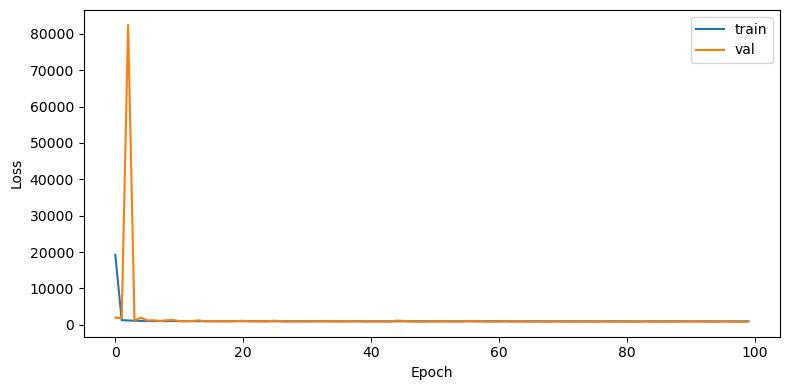

In [7]:
plot_train_val_losses(train_losses, val_losses)

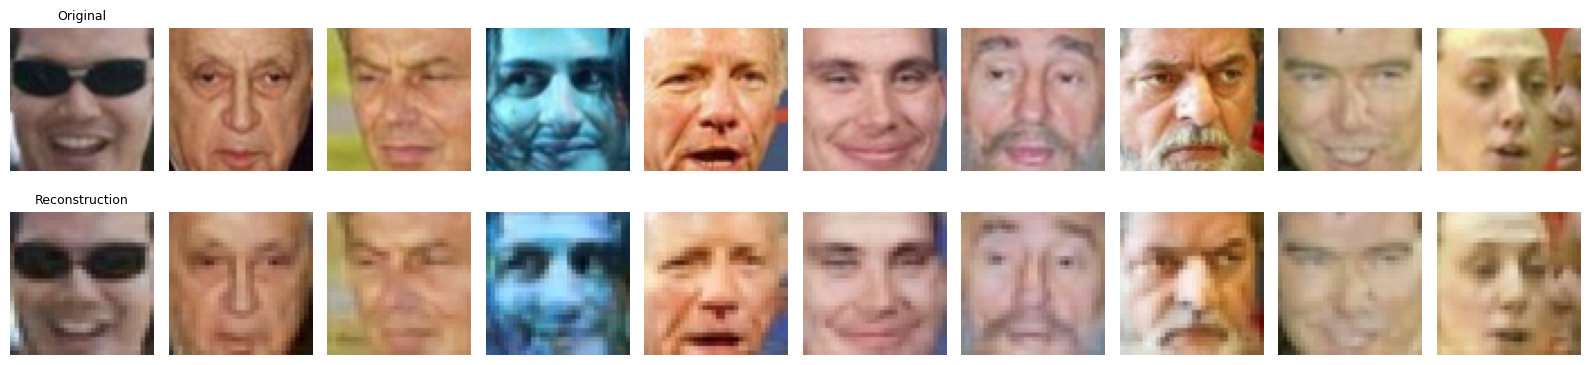

In [8]:
reconstruct(model, val_loader, device, temperature=EVAL_TAU)